In [ ]:
import pandas as pd

url = "https://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST007001-GCST008000/GCST007515/T2D_TranEthnic.BMIunadjusted.txt"
gwas_data = pd.read_csv(url, delimiter="\t")  # Adjust delimiter if needed
gwas_data.head()


,rsID,SNP,CHR,BP,EFFECT_ALLELE,OTHER_ALLELE,avrEAF,Neff,BETA,SE,Pvalue
0,.,1:100049785,1,100049785,A,C,0.4301,200507.0,-0.0028,0.0065,0.42880
1,.,1:100174455,1,100174455,T,C,0.9935,10979.0,-0.3223,0.1938,0.10270
2,.,1:100203648,1,100203648,T,C,0.3575,205051.0,-0.0127,0.0068,0.04527
3,.,1:100316589,1,100316589,A,G,0.5202,209404.0,-0.0021,0.0064,0.76220
4,.,1:100376448,1,100376448,A,G,0.5050,198360.0,0.0008,0.0065,0.61120



1. Loading the data
2. Filter out rows with p-values greater than 0.05 (non-significant)
3. filter out low-frequency SNPs
4.Drop rows with missing values




In [ ]:

gwas_data = gwas_data[gwas_data['Pvalue'] < 0.05]


gwas_data = gwas_data[gwas_data['avrEAF'] > 0.01]


gwas_data = gwas_data.dropna(subset=['BETA', 'Pvalue'])


 Extracting the relevant features for clustering (e.g., Beta and -log10(P-value))

In [ ]:
import pandas as pd
import numpy as np


url = "https://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST007001-GCST008000/GCST007515/T2D_TranEthnic.BMIunadjusted.txt"
gwas_data = pd.read_csv(url, delimiter="\t")

gwas_data.head()

gwas_data = gwas_data[gwas_data['Pvalue'] < 0.05]

gwas_data = gwas_data[gwas_data['avrEAF'] > 0.01]

gwas_data = gwas_data.dropna(subset=['BETA', 'Pvalue'])

from sklearn.preprocessing import StandardScaler


gwas_data['logP'] = -np.log10(gwas_data['Pvalue']) # np is now defined

features = ['BETA', 'logP']

# Standardizing the features (doubt)
scaler = StandardScaler()
gwas_scaled = scaler.fit_transform(gwas_data[features])

 Applying PCA to reduce to 2 dimensions for visualization

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
gwas_pca = pca.fit_transform(gwas_scaled)
pca_df = pd.DataFrame(gwas_pca, columns=['PCA1', 'PCA2'])


Choose the number of clusters (this will be optimized using the elbow method)

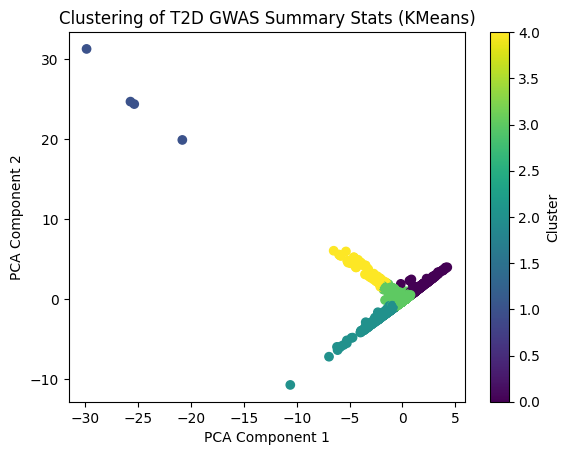

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=5, random_state=42)
gwas_data['Cluster'] = kmeans.fit_predict(gwas_pca)


plt.scatter(gwas_pca[:, 0], gwas_pca[:, 1], c=gwas_data['Cluster'], cmap='viridis')
plt.title('Clustering of T2D GWAS Summary Stats (KMeans)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()



In [ ]:


cluster_1_snps = gwas_data[gwas_data['Cluster'] == 0]  # Get SNPs in cluster 1 (cluster labels start at 0)
print(cluster_1_snps[['SNP', 'BETA', 'logP']])  # Print relevant information for these SNPs

                 SNP    BETA      logP
41        1:10229125  0.2896  1.301204
148       1:10510063  0.2819  1.577082
163       1:10544883  0.3366  1.957818
180       1:10570229  0.3330  1.895854
523      1:114421971  0.5151  1.449405
...              ...     ...       ...
191471   22:44332974  0.3407  1.728391
192085  23:119388489  0.3355  1.564315
192288  23:132159511  0.8327  1.721933
192596  23:147919181  0.6609  1.551758
193025   23:17744556  0.3253  1.623241

[524 rows x 3 columns]


 Elbow Method to find the optimal number of clusters

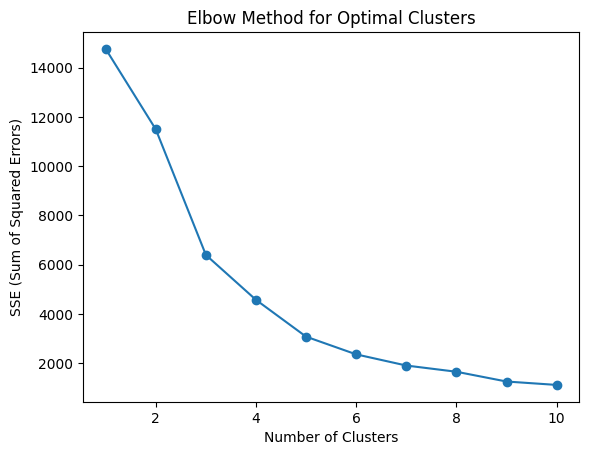

In [ ]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(gwas_pca)
    sse.append(kmeans.inertia_)  # Sum of squared distances to centroids


plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Elbow Method for Optimal Clusters')
plt.show()


 Applying KMeans with optimal number of clusters

---
 Computing the silhouette score to evaluate the clustering quality



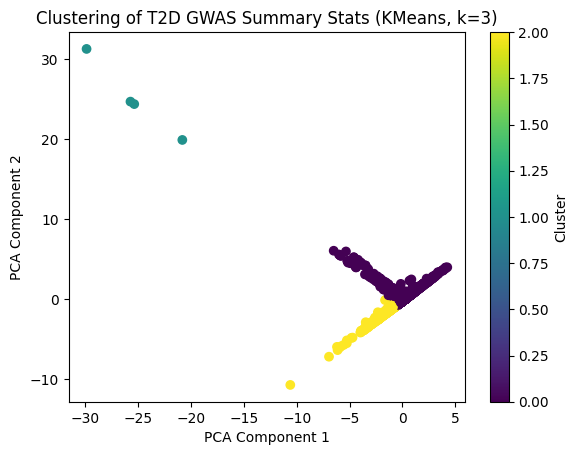

Silhouette Score for k=3: 0.6902


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

optimal_k = 3


kmeans = KMeans(n_clusters=optimal_k, random_state=42)
gwas_data['Cluster'] = kmeans.fit_predict(gwas_pca)

plt.scatter(gwas_pca[:, 0], gwas_pca[:, 1], c=gwas_data['Cluster'], cmap='viridis')
plt.title(f'Clustering of T2D GWAS Summary Stats (KMeans, k={optimal_k})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()


sil_score = silhouette_score(gwas_pca, gwas_data['Cluster'])
print(f"Silhouette Score for k={optimal_k}: {sil_score:.4f}")



In [ ]:

for cluster_id in range(optimal_k):
    cluster_snps = gwas_data[gwas_data['Cluster'] == cluster_id]
    print(f"SNPs in Cluster {cluster_id}:")
    print(cluster_snps[['SNP', 'BETA', 'logP']])
    cluster_snps.to_csv(f"cluster_{cluster_id}_snps.csv", index=False)


SNPs in Cluster 0:
                SNP    BETA      logP
2       1:100203648 -0.0127  1.344190
27       1:10155283 -0.2567  2.274088
41       1:10229125  0.2896  1.301204
79      1:103216881  0.0139  1.572676
111     1:104484650  0.0127  1.320572
...             ...     ...       ...
194390  23:77913569  0.0134  1.427477
194404  23:78618948 -0.0592  1.675512
194424  23:80370502  0.1900  2.124823
194436  23:82551290 -0.0216  1.552532
194529  23:89712929 -0.1241  1.508778

[6805 rows x 3 columns]
SNPs in Cluster 1:
                 SNP    BETA        logP
102641  10:114754088 -0.2068  225.235077
102642  10:114756041 -0.2158  228.211832
102643  10:114758349  0.2325  276.273273
102656  10:114788815 -0.1933  184.806875
SNPs in Cluster 2:
                SNP    BETA      logP
11      1:100606023 -0.9044  2.752272
506     1:114367858 -0.4553  1.571865
790     1:145112468 -0.7240  1.359519
1673    1:178491570 -1.4812  1.924088
2132    1:203743490 -0.9173  1.628932
...             ...     ...  

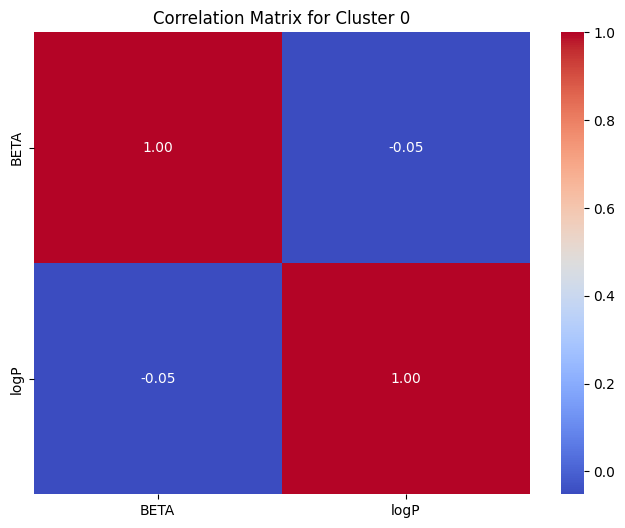

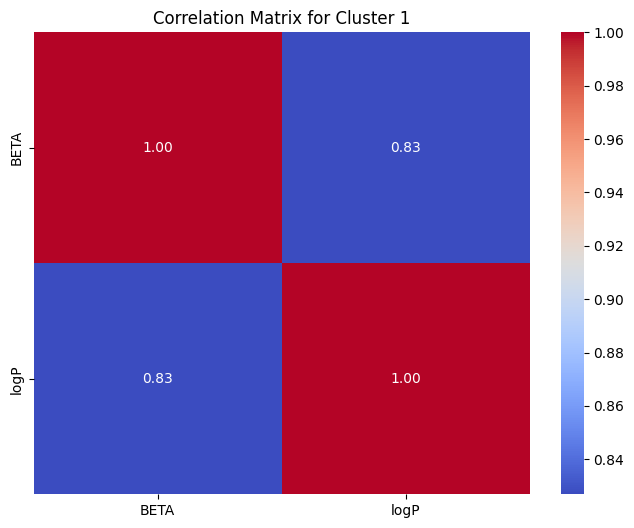

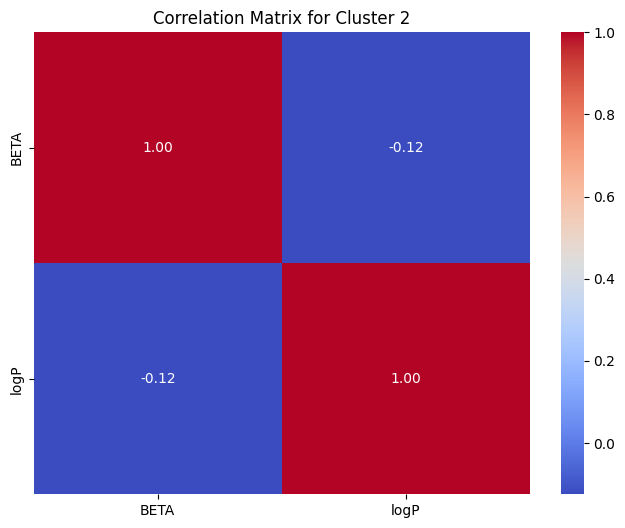

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for cluster_id in range(optimal_k):
      cluster_snps = gwas_data[gwas_data['Cluster'] == cluster_id]

      # Select features for correlation analysis
      features = ['BETA', 'logP']

      # Calculate correlation matrix
      correlation_matrix = cluster_snps[features].corr()

      # Plot correlation matrix as a heatmap
      plt.figure(figsize=(8, 6))
      sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
      plt.title(f'Correlation Matrix for Cluster {cluster_id}')
      plt.show()

Correlation coefficient for Cluster 0: -0.051890012479835


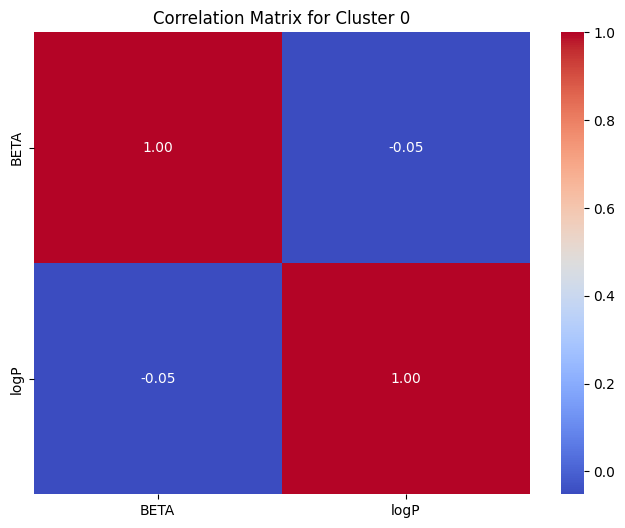

Correlation coefficient for Cluster 1: 0.8268934050624629


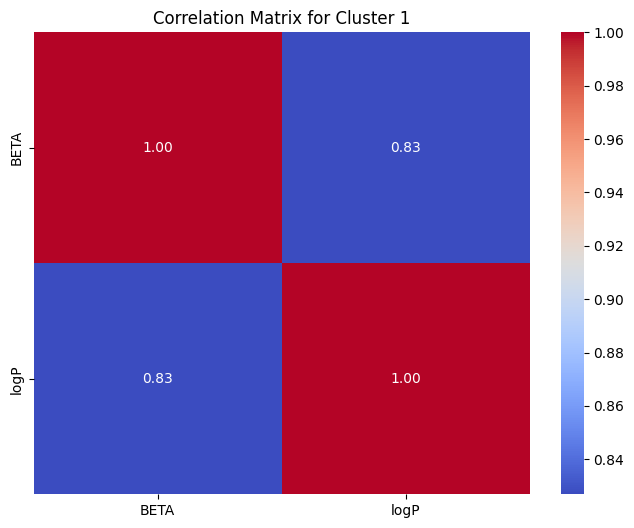

Correlation coefficient for Cluster 2: -0.12489138476782932


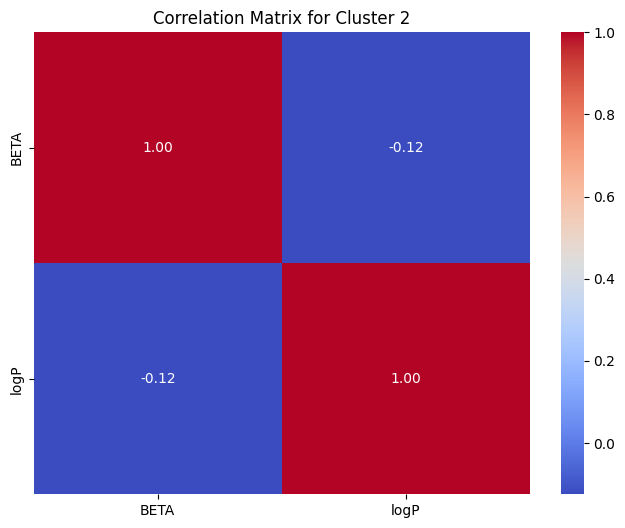

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for cluster_id in range(optimal_k):
    cluster_snps = gwas_data[gwas_data['Cluster'] == cluster_id]

    # CalculatING correlation coefficient for 'BETA' and 'logP' within the cluster
    correlation_coefficient = cluster_snps['BETA'].corr(cluster_snps['logP'])

    print(f"Correlation coefficient for Cluster {cluster_id}: {correlation_coefficient}")

    #  correlation matrix as a heatmap for visualization
    features = ['BETA', 'logP']
    correlation_matrix = cluster_snps[features].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Matrix for Cluster {cluster_id}')
    plt.show()

In [ ]:
snps = pd.read_csv("/content/cluster_snps.bed", sep='\t', header=None)
print(snps.head())


   0          1          2            3
0  1  100606023  100606023  1:100606023
1  1  114367858  114367858  1:114367858
2  1  145112468  145112468  1:145112468
3  1  178491570  178491570  1:178491570
4  1  203743490  203743490  1:203743490


In [ ]:
genes = pd.read_csv('/content/genes.bed', sep='\t', header=None)
print(genes.head())


    0          1     2  3      4      5      6      7   8   \
0  585  NR_024540  chr1  -  14361  29370  29370  29370  11   
1  585  NR_106918  chr1  -  17368  17436  17436  17436   1   
2  585  NR_107062  chr1  -  17368  17436  17436  17436   1   
3  585  NR_107063  chr1  -  17368  17436  17436  17436   1   
4  585  NR_128720  chr1  -  17368  17436  17436  17436   1   

                                                  9   \
0  14361,14969,15795,16606,16857,17232,17605,1791...   
1                                             17368,   
2                                             17368,   
3                                             17368,   
4                                             17368,   

                                                  10  11         12   13   14  \
0  14829,15038,15947,16765,17055,17368,17742,1806...   0     WASH7P  unk  unk   
1                                             17436,   0  MIR6859-1  unk  unk   
2                                             1

In [ ]:
import pandas as pd


for cluster_id in range(optimal_k):
    cluster_snps = gwas_data[gwas_data['Cluster'] == cluster_id]

    bed_data = cluster_snps[['CHR', 'BP', 'BP', 'SNP']]

    # Save to BED file
    bed_file_name = f"cluster_{cluster_id}_snps.bed"
    bed_data.to_csv(bed_file_name, sep='\t', index=False, header=False)
    print(f"Cluster {cluster_id} SNPs saved to: {bed_file_name}")

Cluster 0 SNPs saved to: cluster_0_snps.bed
Cluster 1 SNPs saved to: cluster_1_snps.bed
Cluster 2 SNPs saved to: cluster_2_snps.bed


In [ ]:
import pandas as pd

# Replace with the path to your CSV file (e.g., for cluster_0)
df = pd.read_csv("cluster_1_snps.csv")

# Inspect the RSID column
print(df["rsID"].head())

# Filter out empty or invalid RSIDs (assuming valid ones are not ".")
rsids = df["rsID"].dropna()
rsids = rsids[rsids != "."]

# Optionally, remove duplicates
rsids = rsids.drop_duplicates()

# Save the RSIDs to a text file, one per line
rsids.to_csv("cluster_1_rsids.txt", index=False, header=False)

print("RSID list saved!")


0    .
1    .
2    .
3    .
Name: rsID, dtype: object
RSID list saved!


In [ ]:
import pandas as pd
df = pd.read_csv("/content/cluster_0_snps.csv")
# Finding lead SNP in each cluster (smallest p-value)
lead_snps = df.loc[df.groupby("Cluster")["Pvalue"].idxmin()]

print("Lead SNPs in  Cluster 0:")
print(lead_snps)


Lead SNPs in  Cluster 0:
     rsID         SNP  CHR        BP EFFECT_ALLELE OTHER_ALLELE  avrEAF  \
2150    .  6:20679709    6  20679709             A            G  0.6836   

          Neff    BETA      SE        Pvalue       logP  Cluster  
2150  212002.0 -0.1025  0.0065  1.864000e-59  58.729554        0  


In [ ]:
df = pd.read_csv("/content/cluster_1_snps.csv")
lead_snps = df.loc[df.groupby("Cluster")["Pvalue"].idxmin()]

print("Lead SNPs per Cluster:")
print(lead_snps)

Lead SNPs per Cluster:
  rsID           SNP  CHR         BP EFFECT_ALLELE OTHER_ALLELE  avrEAF  \
2    .  10:114758349   10  114758349             T            C  0.2665   

       Neff    BETA      SE         Pvalue        logP  Cluster  
2  212002.0  0.2325  0.0067  5.330000e-277  276.273273        1  


In [ ]:

df = pd.read_csv("/content/cluster_2_snps.csv")
lead_snps = df.loc[df.groupby("Cluster")["Pvalue"].idxmin()]

print("Lead SNPs per Cluster:")
print(lead_snps)

Lead SNPs per Cluster:
    rsID         SNP  CHR       BP EFFECT_ALLELE OTHER_ALLELE  avrEAF    Neff  \
320    .  11:2858440   11  2858440             A            G  0.3397  2999.0   

       BETA      SE        Pvalue     logP  Cluster  
320 -0.3428  0.0551  4.138000e-10  9.38321        2  


In [ ]:
import requests

def get_rsid(chr, pos):
    url = f"https://rest.ensembl.org/overlap/region/human/{chr}:{pos}-{pos}?feature=variation"
    headers = {"Content-Type": "application/json"}
    response = requests.get(url, headers=headers)

    if response.ok:
        data = response.json()
        if data:
            return data[0].get("id", "No rsID found")  # Extracting rsID
    return "No rsID found"

# Cluster 0
chr_num = 6
bp_position = 20679709
rsid = get_rsid(chr_num, bp_position)

print(f"Chromosome {chr_num}, Position {bp_position} → rsID: {rsid}")


Chromosome 6, Position 20679709 → rsID: rs1179211133


In [ ]:
import requests

def get_rsid(chr, pos):
    url = f"https://rest.ensembl.org/overlap/region/human/{chr}:{pos}-{pos}?feature=variation"
    headers = {"Content-Type": "application/json"}
    response = requests.get(url, headers=headers)

    if response.ok:
        data = response.json()
        if data:
            return data[0].get("id", "No rsID found")
    return "No rsID found"

# Cluster 1
chr_num = 10
bp_position = 114758349
rsid = get_rsid(chr_num, bp_position)

print(f"Chromosome {chr_num}, Position {bp_position} → rsID: {rsid}")


Chromosome 10, Position 114758349 → rsID: rs2082675528


In [ ]:
import requests

def get_rsid(chr, pos):
    url = f"https://rest.ensembl.org/overlap/region/human/{chr}:{pos}-{pos}?feature=variation"
    headers = {"Content-Type": "application/json"}
    response = requests.get(url, headers=headers)

    if response.ok:
        data = response.json()
        if data:
            return data[0].get("id", "No rsID found")  # Extract rsID
    return "No rsID found"

# Cluster 2
chr_num = 11
bp_position = 2858440
rsid = get_rsid(chr_num, bp_position)

print(f"Chromosome {chr_num}, Position {bp_position} → rsID: {rsid}")

Chromosome 11, Position 2858440 → rsID: rs990360018
